# Prediksi Rata-rata Parameter Produksi Bulan Depan (Per-Parameter) — MT-620

Notebook ini memprediksi **rata-rata bulanan** dari **12 parameter QC** secara **terpisah**
(masing-masing parameter punya model XGBoost sendiri), untuk **bulan berikutnya**.

## Metodologi

1. Data batch diagregasi menjadi **rata-rata per bulan** (meredam noise antar-batch).
2. **EDA**: statistik deskriptif, distribusi, korelasi.
3. **Uji Normalitas** (Shapiro-Wilk) & **Uji Stasioneritas** (ADF) sebagai validasi asumsi.
4. Untuk **setiap parameter**, dilakukan secara independen:
   - Feature engineering (lag-1, lag-2, lag-3, rolling mean, bulan, tahun)
   - Train-test split **berurutan waktu** (~80%/20%)
   - Training & hyperparameter tuning XGBoost (RandomizedSearchCV)
   - Evaluasi: MAE, RMSE, MAPE, R²
   - Cross-validation (TimeSeriesSplit) & walk-forward validation
5. Prediksi bulan depan dengan **interval kepercayaan 95%**.

## Parameter yang Diprediksi

| No | Kode | Nama Lengkap |
|----|------|-------------|
| 1 | Transmission | Transmission |
| 2 | Tin | Tin Content |
| 3 | RI | RI @ 25°C |
| 4 | SG | SG @ 25°C |
| 5 | Acid | Acid Value |
| 6 | Sulfur | Sulfur |
| 7 | Water | Water Content |
| 8 | Mono | Monomethyltin |
| 9 | Yellow | Yellowish Index |
| 10 | EH | 2-EH |
| 11 | Visco | Viscosity |
| 12 | PT | Pt-Co |

> **Catatan:** Appearance (APE) berisi data **kategorikal** ("Clear") sehingga tidak bisa
> diprediksi dengan model regresi. Parameter ini dikecualikan dari prediksi numerik.

**Referensi utama:**
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* ACM SIGKDD.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.

## 1. Import Library & Load Data

**Referensi:** McKinney, W. (2017). *Python for Data Analysis*, 2nd Ed. O'Reilly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# --- Load Data ---
file_path = r"Data_Chemical_2026.04-16-MT620.xlsx"
df = pd.read_excel(file_path)

# Daftar parameter numerik (APE dikecualikan karena kategorikal)
param_codes = ['Transmission','Tin','RI','SG','Acid','Sulfur','Water','Mono','Yellow','EH','Visco','PT']
param_names = {
    'Transmission': 'Transmission',
    'Tin': 'Tin Content',
    'RI': 'RI @ 25\u00b0C',
    'SG': 'SG @ 25\u00b0C',
    'Acid': 'Acid Value',
    'Sulfur': 'Sulfur',
    'Water': 'Water Content',
    'Mono': 'Monomethyltin',
    'Yellow': 'Yellowish Index',
    'EH': '2-EH',
    'Visco': 'Viscosity',
    'PT': 'Pt-Co'
}

print(f'Shape awal: {df.shape}')
print(f'Kolom: {list(df.columns)}')
print(f'Parameter numerik: {len(param_codes)} parameter')
print(f'APE (Appearance) dikecualikan: data kategorikal')

Shape awal: (1851, 19)
Kolom: ['No', 'Nama Chemical', 'Nama', 'Tanggal', 'Jam Masuk', 'Batch', 'Transmission', 'APE', 'Tin', 'RI', 'SG', 'Acid', 'Sulfur', 'Water', 'Mono', 'Yellow', 'EH', 'Visco', 'PT']
Parameter numerik: 12 parameter
APE (Appearance) dikecualikan: data kategorikal


## 2. Data Cleaning & Agregasi per Bulan

Data batch diagregasi menjadi rata-rata per bulan untuk meredam noise antar-batch.

**Referensi:** Hyndman, R. J., & Athanasopoulos, G. (2021). *FPP3*, Bab 2: Time Series Graphics.

In [2]:
df = df.drop_duplicates()
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df = df.dropna(subset=['Tanggal'])
for c in param_codes:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=param_codes, how='any').reset_index(drop=True)
df['bulan'] = df['Tanggal'].dt.to_period('M')

# Agregasi: rata-rata per bulan
mon = df.groupby('bulan')[param_codes].mean()
mon.index = mon.index.to_timestamp()  # konversi ke datetime untuk fitur month/year

print(f'Jumlah bulan: {len(mon)} | Rentang: {mon.index.min().strftime("%Y-%m")} s/d {mon.index.max().strftime("%Y-%m")}')
print(f'Jumlah batch total: {len(df)}')
mon.round(4)

Jumlah bulan: 12 | Rentang: 2025-05 s/d 2026-04
Jumlah batch total: 1844


,Transmission,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
bulan,,,,,,,,,,,,
2025-05-01,98.9966,19.0755,1.5090,1.1710,1.1247,11.9947,2.4047,23.8040,7.9905,0.2477,60.5772,14.4938
2025-06-01,99.0806,19.1013,1.5094,1.1698,0.9079,11.9823,2.6061,23.5237,7.9934,0.1935,58.1516,13.2214
2025-07-01,99.0156,19.0802,1.5110,1.1696,0.9871,12.0097,2.3833,23.6594,8.0611,0.2313,58.3211,14.1347
2025-08-01,99.0384,19.1246,1.5113,1.1716,0.9260,12.0028,2.4088,23.3902,8.1799,0.2057,57.9180,13.5269
2025-09-01,98.9932,19.0687,1.5102,1.1709,1.1437,11.9284,2.3781,23.6821,8.0883,0.2395,56.8411,14.9759
2025-10-01,98.9907,19.0542,1.5095,1.1707,1.1794,11.9426,2.2793,23.6646,7.8951,0.2580,57.2129,14.0208
2025-11-01,98.9931,19.0943,1.5097,1.1708,1.1236,11.9041,2.3228,23.7399,7.9054,0.2299,57.7690,15.1181
2025-12-01,99.0128,19.0434,1.5095,1.1700,1.1461,11.9194,2.2403,23.3514,7.8741,0.2526,57.4214,14.5198
2026-01-01,98.9409,19.0312,1.5096,1.1702,1.2409,11.9034,2.3615,23.6399,7.8382,0.2411,59.0400,13.7328


## 3. Exploratory Data Analysis (EDA)

Memahami distribusi, pola, dan hubungan antar parameter sebelum pemodelan.

**Referensi:** McKinney, W. (2017). *Python for Data Analysis*, 2nd Ed. O'Reilly.

=== Statistik Deskriptif (Rata-rata Bulanan) ===


,Transmission,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
count,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000
mean,99.0022,19.0639,1.5100,1.1705,1.0897,11.9629,2.3688,23.5595,7.9692,0.2352,58.0202,14.3716
std,0.0347,0.0337,0.0007,0.0006,0.1114,0.0407,0.1015,0.1653,0.1120,0.0186,0.9824,0.8798
min,98.9409,19.0127,1.5090,1.1696,0.9079,11.9034,2.2403,23.2927,7.8136,0.1935,56.8411,13.2214
25%,98.9895,19.0404,1.5095,1.1699,0.9819,11.9261,2.2915,23.4082,7.8898,0.2309,57.4543,13.6813
50%,98.9949,19.0639,1.5098,1.1705,1.1342,11.9765,2.3698,23.5960,7.9603,0.2403,57.8090,14.3143
75%,99.0135,19.0837,1.5103,1.1709,1.1630,11.9966,2.4057,23.6689,8.0608,0.2443,58.1940,15.0114
max,99.0806,19.1246,1.5113,1.1716,1.2409,12.0097,2.6061,23.8040,8.1799,0.2580,60.5772,16.0133


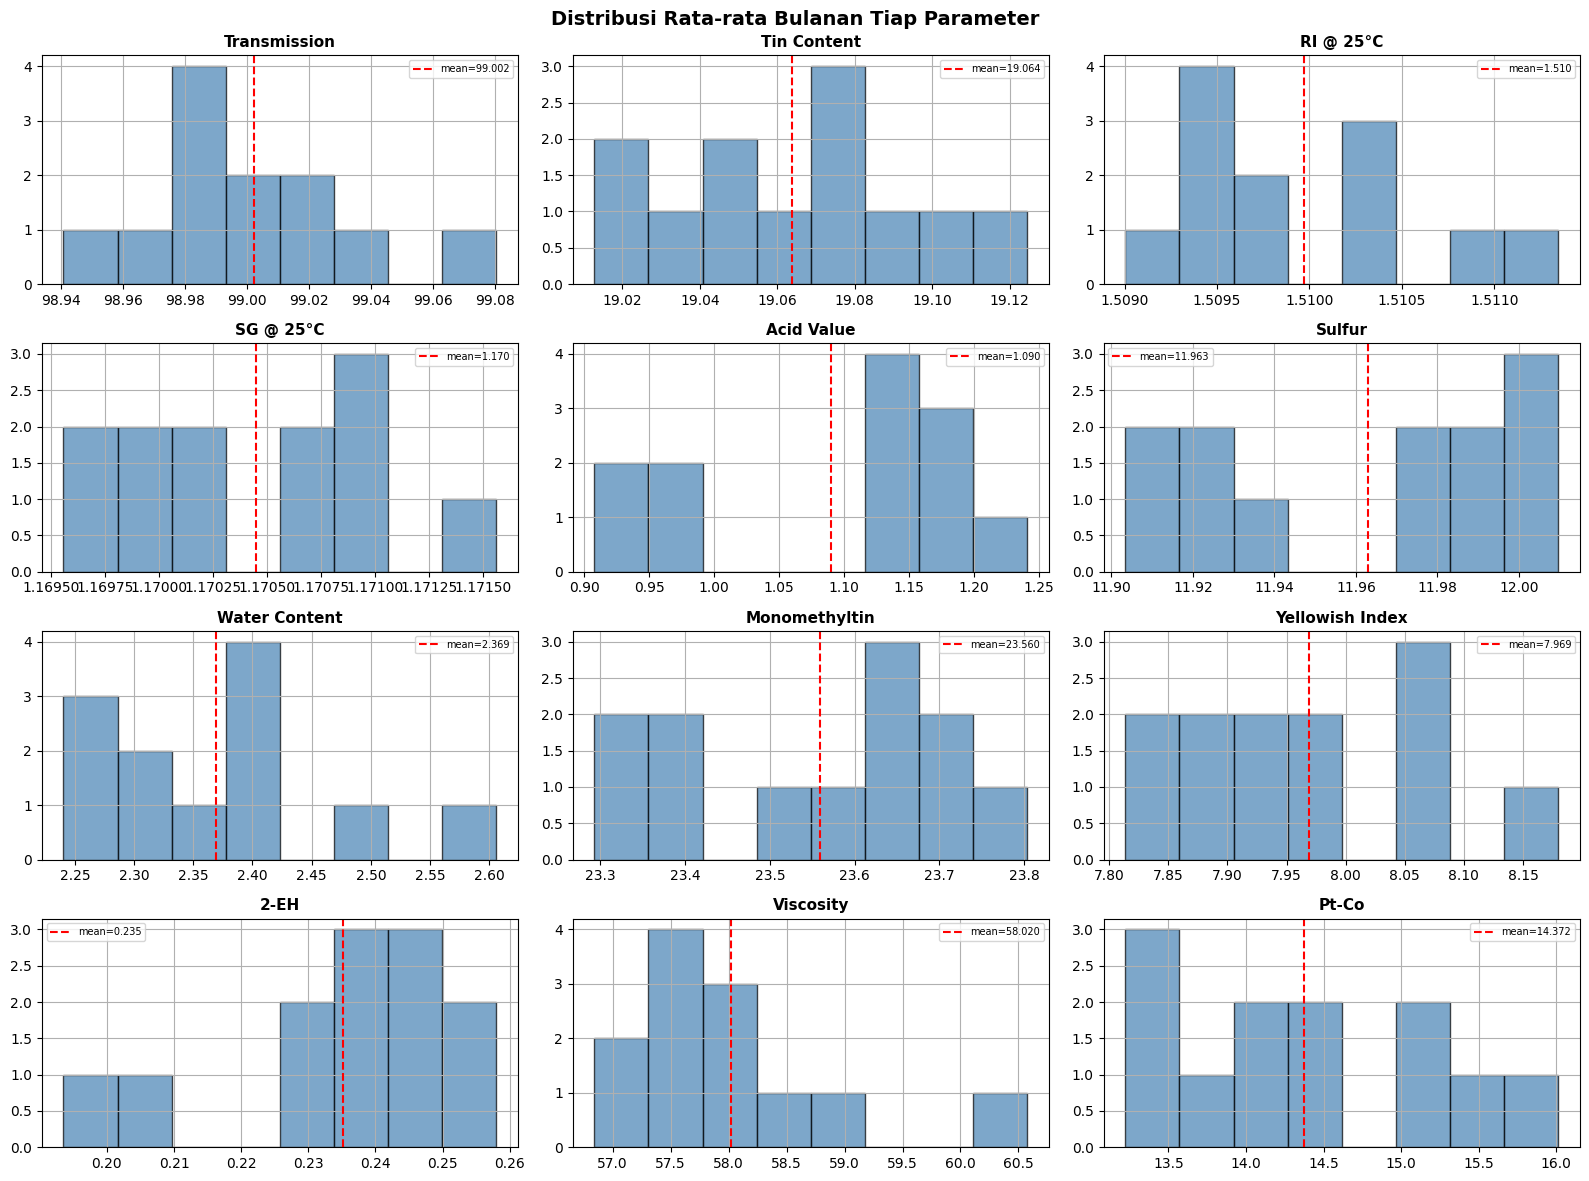

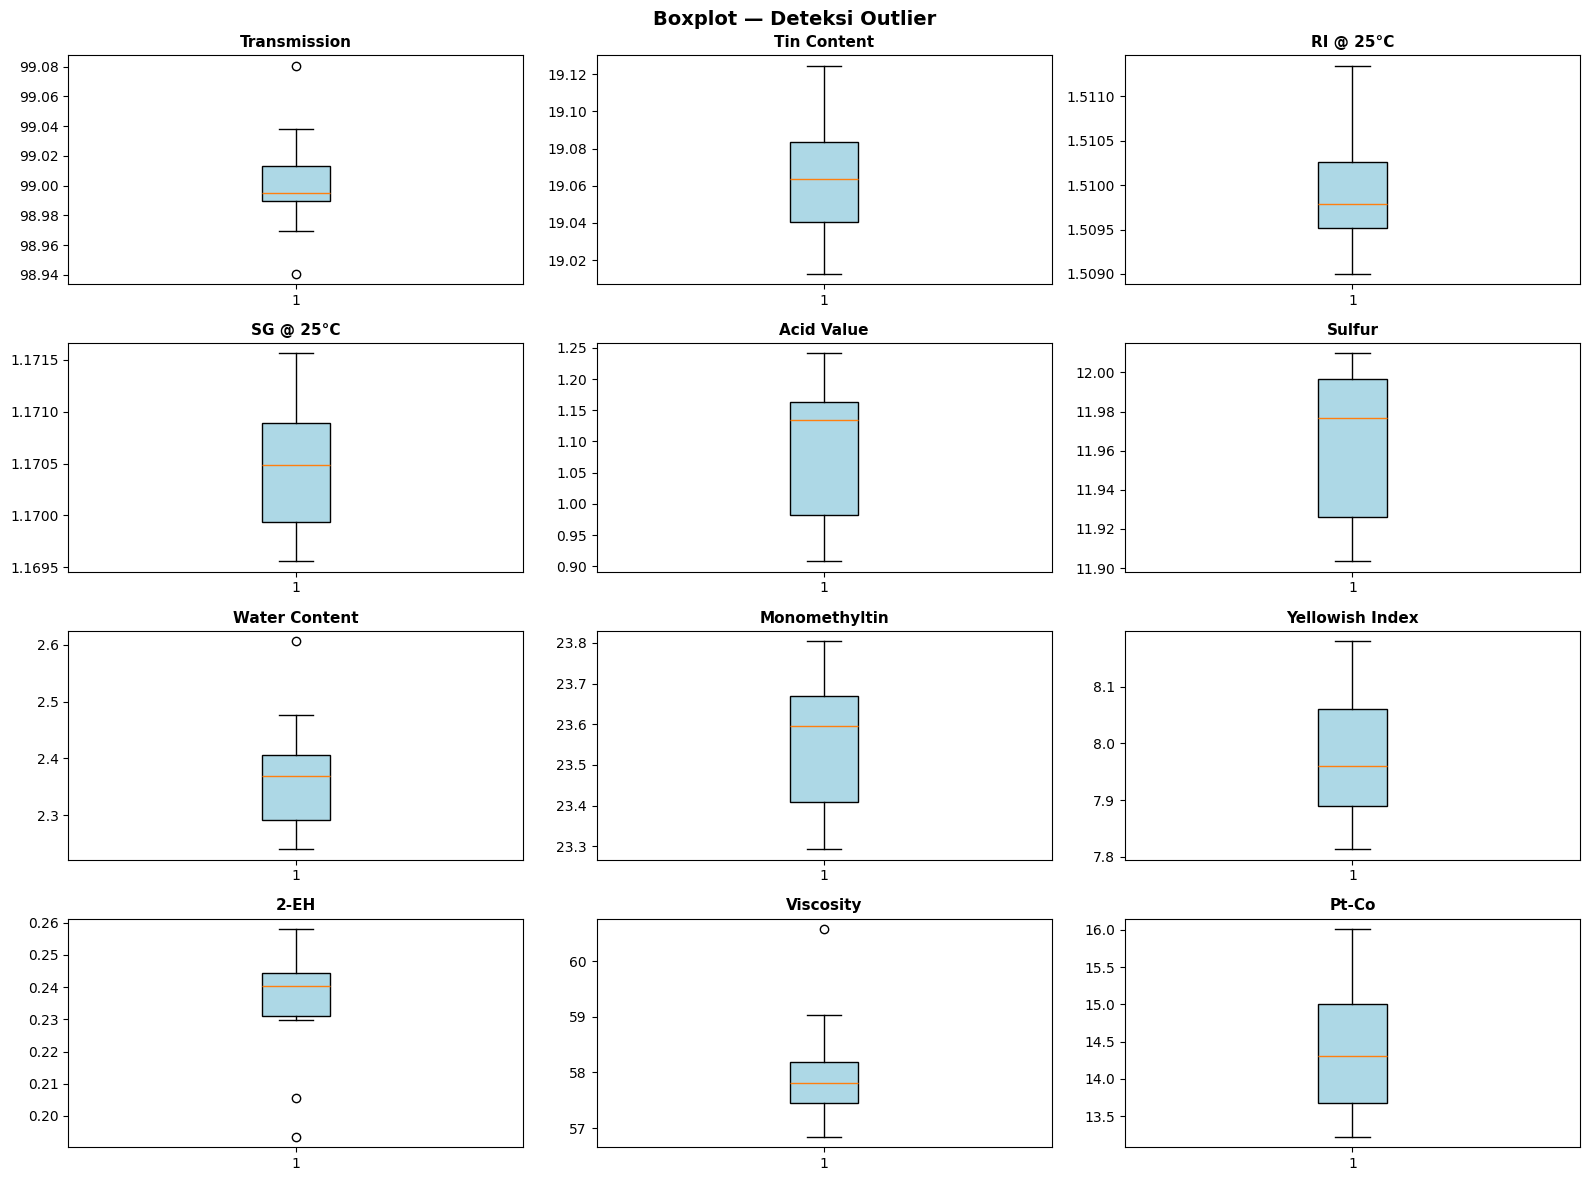

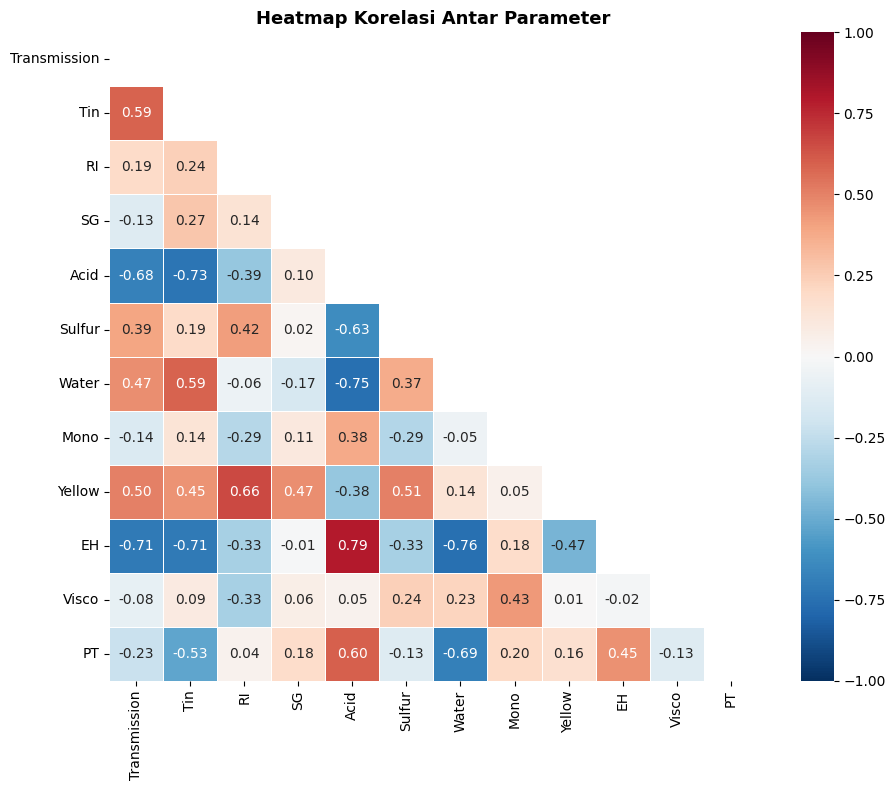

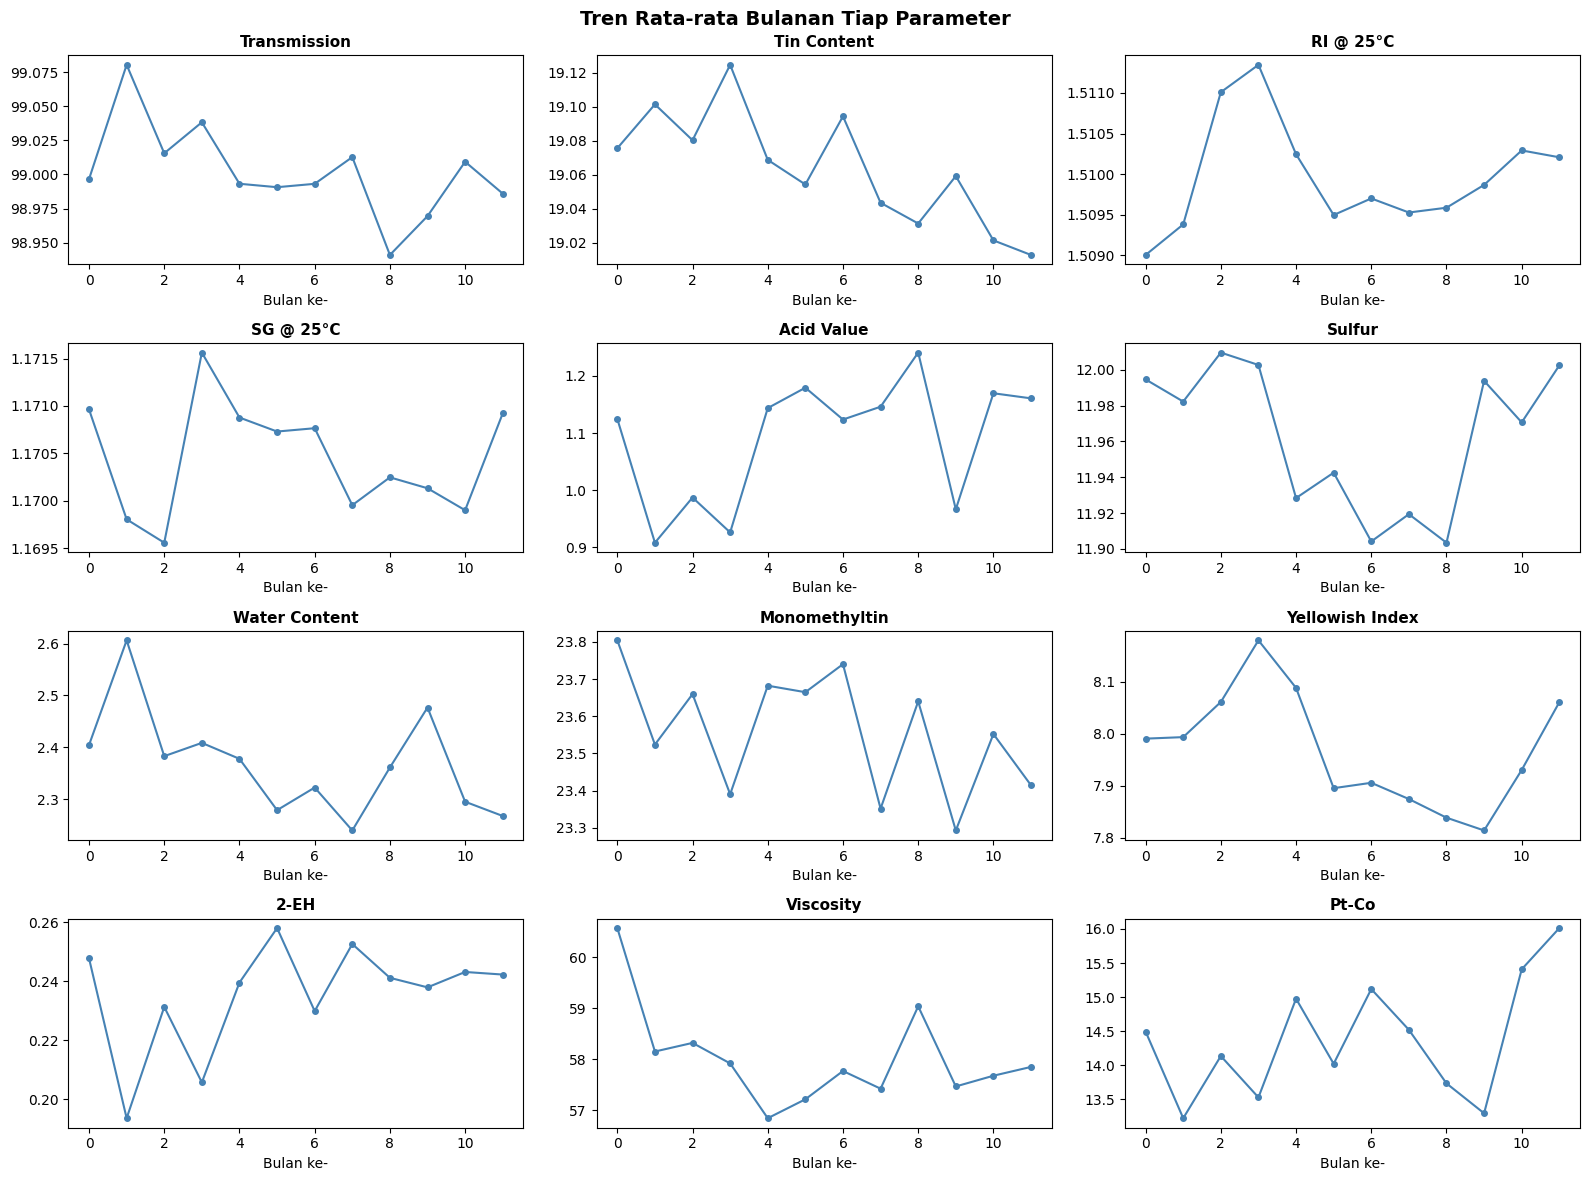

In [3]:
# --- 3a. Statistik Deskriptif ---
print("=== Statistik Deskriptif (Rata-rata Bulanan) ===")
display(mon.describe().round(4))

# --- 3b. Histogram ---
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), param_codes):
    mon[c].hist(ax=ax, bins=8, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'{param_names[c]}', fontsize=11, fontweight='bold')
    ax.axvline(mon[c].mean(), color='red', linestyle='--', label=f'mean={mon[c].mean():.3f}')
    ax.legend(fontsize=7)
plt.suptitle('Distribusi Rata-rata Bulanan Tiap Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3c. Boxplot ---
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), param_codes):
    ax.boxplot(mon[c].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(f'{param_names[c]}', fontsize=11, fontweight='bold')
plt.suptitle('Boxplot — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3d. Heatmap Korelasi ---
plt.figure(figsize=(10, 8))
corr = mon.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Parameter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3e. Time Series Plot ---
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), param_codes):
    ax.plot(range(len(mon)), mon[c].values, 'o-', color='steelblue', markersize=4)
    ax.set_title(f'{param_names[c]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Bulan ke-')
plt.suptitle('Tren Rata-rata Bulanan Tiap Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Uji Normalitas (Shapiro-Wilk Test)

Menguji apakah data berdistribusi normal — penting untuk validitas interval kepercayaan.
- **H₀:** Data berdistribusi normal
- **H₁:** Data TIDAK berdistribusi normal
- Jika **p-value > 0.05**, maka data dianggap normal.

**Referensi:** Shapiro, S. S., & Wilk, M. B. (1965). "An Analysis of Variance Test for Normality."
*Biometrika*, 52(3/4), 591–611. [DOI: 10.2307/2333709](https://doi.org/10.2307/2333709)

In [4]:
hasil_normalitas = []
for c in param_codes:
    data = mon[c].dropna().values
    if len(data) >= 3:
        stat_w, p_val = stats.shapiro(data)
        hasil_normalitas.append({
            'Parameter': param_names[c],
            'Kode': c,
            'W-Statistic': round(stat_w, 4),
            'p-value': round(p_val, 4),
            'Keterangan': "Normal" if p_val > 0.05 else "Tidak Normal"
        })

df_normal = pd.DataFrame(hasil_normalitas)
print("=== Hasil Uji Normalitas Shapiro-Wilk (\u03b1 = 0.05) ===")
display(df_normal)

n_normal = (df_normal['Keterangan'] == 'Normal').sum()
print(f'\n\u2192 {n_normal} dari {len(param_codes)} parameter berdistribusi normal.')

=== Hasil Uji Normalitas Shapiro-Wilk (α = 0.05) ===


,Parameter,Kode,W-Statistic,p-value,Keterangan
0,Transmission,Transmission,0.9400,0.4976,Normal
1,Tin Content,Tin,0.9837,0.9944,Normal
2,RI @ 25°C,RI,0.9303,0.3831,Normal
3,SG @ 25°C,SG,0.9461,0.5805,Normal
4,Acid Value,Acid,0.8700,0.0653,Normal
5,Sulfur,Sulfur,0.8715,0.0683,Normal
6,Water Content,Water,0.9230,0.3121,Normal
7,Monomethyltin,Mono,0.9440,0.5515,Normal
8,Yellowish Index,Yellow,0.9597,0.7796,Normal
9,2-EH,EH,0.8665,0.0591,Normal



→ 11 dari 12 parameter berdistribusi normal.


## 5. Uji Stasioneritas (Augmented Dickey-Fuller Test)

Menguji apakah deret waktu memiliki unit root (non-stasioner).
- **H₀:** Data memiliki unit root (non-stasioner)
- **H₁:** Data stasioner
- Jika **p-value < 0.05**, maka data **stasioner**.

**Referensi:** Dickey, D. A., & Fuller, W. A. (1979). "Distribution of the Estimators for
Autoregressive Time Series with a Unit Root." *JASA*, 74(366), 427–431.
[DOI: 10.2307/2286348](https://doi.org/10.2307/2286348)

In [5]:
hasil_stasioner = []
for c in param_codes:
    data = mon[c].dropna().values
    if len(data) >= 4:
        try:
            adf_stat, p_val, used_lag, nobs, crit_vals, icbest = adfuller(data, maxlag=2)
            hasil_stasioner.append({
                'Parameter': param_names[c],
                'Kode': c,
                'ADF Statistic': round(adf_stat, 4),
                'p-value': round(p_val, 4),
                'Critical 5%': round(crit_vals['5%'], 4),
                'Keterangan': "Stasioner" if p_val < 0.05 else "Non-Stasioner"
            })
        except Exception as e:
            hasil_stasioner.append({
                'Parameter': param_names[c], 'Kode': c,
                'ADF Statistic': '-', 'p-value': '-',
                'Critical 5%': '-', 'Keterangan': f'Error: {e}'
            })

df_stasioner = pd.DataFrame(hasil_stasioner)
print("=== Hasil Uji Stasioneritas ADF (\u03b1 = 0.05) ===")
display(df_stasioner)

n_s = (df_stasioner['Keterangan'] == 'Stasioner').sum()
n_ns = (df_stasioner['Keterangan'] == 'Non-Stasioner').sum()
print(f'\nStasioner: {n_s} | Non-Stasioner: {n_ns}')
print('Parameter non-stasioner memiliki tren -> XGBoost dengan fitur lag cocok untuk menangkapnya.')

=== Hasil Uji Stasioneritas ADF (α = 0.05) ===


,Parameter,Kode,ADF Statistic,p-value,Critical 5%,Keterangan
0,Transmission,Transmission,-2.5648,0.1005,-3.1894,Non-Stasioner
1,Tin Content,Tin,0.3565,0.9798,-3.2899,Non-Stasioner
2,RI @ 25°C,RI,-4.2781,0.0005,-3.2330,Stasioner
3,SG @ 25°C,SG,-3.1501,0.0231,-3.1894,Stasioner
4,Acid Value,Acid,-2.6207,0.0888,-3.1894,Non-Stasioner
5,Sulfur,Sulfur,-2.1239,0.2350,-3.2899,Non-Stasioner
6,Water Content,Water,-2.2997,0.1721,-3.1894,Non-Stasioner
7,Monomethyltin,Mono,-4.5631,0.0002,-3.1894,Stasioner
8,Yellowish Index,Yellow,-1.9665,0.3015,-3.2330,Non-Stasioner
9,2-EH,EH,-3.2994,0.0149,-3.1894,Stasioner



Stasioner: 5 | Non-Stasioner: 7
Parameter non-stasioner memiliki tren -> XGBoost dengan fitur lag cocok untuk menangkapnya.


## 6. Feature Engineering (Per Parameter)

Untuk setiap parameter, dibuat fitur historis:
- **lag1, lag2, lag3**: nilai 1, 2, 3 bulan sebelumnya
- **rolling_mean_3**: rata-rata bergerak 3 bulan
- **month**: bulan kalender (menangkap pola musiman)
- **year**: tahun (menangkap tren tahunan)

**Referensi:** Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*
(3rd ed.), Bab 7: Time Series Regression Models. [OTexts](https://otexts.com/fpp3/)

In [6]:
def build_features(series):
    """Buat fitur lag dan rolling dari satu deret parameter."""
    feat = pd.DataFrame(index=series.index)
    feat['lag1'] = series.shift(1)
    feat['lag2'] = series.shift(2)
    feat['lag3'] = series.shift(3)
    feat['rolling_mean_3'] = series.shift(1).rolling(3).mean()
    feat['month'] = series.index.month
    feat['year'] = series.index.year
    feat['target'] = series.values
    feat = feat.dropna()
    return feat

# Buat fitur untuk semua parameter
all_features = {}
for c in param_codes:
    all_features[c] = build_features(mon[c])
    print(f'{param_names[c]:20s} -> {len(all_features[c])} sampel tersedia setelah lag')

feature_cols = ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'month', 'year']
print(f'\nFitur: {feature_cols}')

Transmission         -> 9 sampel tersedia setelah lag
Tin Content          -> 9 sampel tersedia setelah lag
RI @ 25°C            -> 9 sampel tersedia setelah lag
SG @ 25°C            -> 9 sampel tersedia setelah lag
Acid Value           -> 9 sampel tersedia setelah lag
Sulfur               -> 9 sampel tersedia setelah lag
Water Content        -> 9 sampel tersedia setelah lag
Monomethyltin        -> 9 sampel tersedia setelah lag
Yellowish Index      -> 9 sampel tersedia setelah lag
2-EH                 -> 9 sampel tersedia setelah lag
Viscosity            -> 9 sampel tersedia setelah lag
Pt-Co                -> 9 sampel tersedia setelah lag

Fitur: ['lag1', 'lag2', 'lag3', 'rolling_mean_3', 'month', 'year']


## 7. Train-Test Split (Berurutan Waktu, Per Parameter)

Split dilakukan **per parameter** dengan menjaga urutan waktu:
- **~80% awal** untuk training
- **~20% akhir** untuk testing

**Referensi:** Hyndman, R. J., & Athanasopoulos, G. (2021). *FPP3*, Bab 5.1: Training and Test Sets.

In [7]:
splits = {}
for c in param_codes:
    data = all_features[c]
    X = data[feature_cols].values
    y = data['target'].values
    n = len(data)
    cut = max(1, int(round(n * 0.8)))
    
    splits[c] = {
        'X_train': X[:cut], 'X_test': X[cut:],
        'y_train': y[:cut], 'y_test': y[cut:],
        'data': data, 'cut': cut
    }
    print(f'{param_names[c]:20s} -> Train: {cut} | Test: {n - cut} | Total: {n}')

print('\nCatatan: Sampel sangat sedikit (~12 bulan). Hasil bersifat indikatif.')

Transmission         -> Train: 7 | Test: 2 | Total: 9
Tin Content          -> Train: 7 | Test: 2 | Total: 9
RI @ 25°C            -> Train: 7 | Test: 2 | Total: 9
SG @ 25°C            -> Train: 7 | Test: 2 | Total: 9
Acid Value           -> Train: 7 | Test: 2 | Total: 9
Sulfur               -> Train: 7 | Test: 2 | Total: 9
Water Content        -> Train: 7 | Test: 2 | Total: 9
Monomethyltin        -> Train: 7 | Test: 2 | Total: 9
Yellowish Index      -> Train: 7 | Test: 2 | Total: 9
2-EH                 -> Train: 7 | Test: 2 | Total: 9
Viscosity            -> Train: 7 | Test: 2 | Total: 9
Pt-Co                -> Train: 7 | Test: 2 | Total: 9

Catatan: Sampel sangat sedikit (~12 bulan). Hasil bersifat indikatif.


## 8. Training & Hyperparameter Tuning XGBoost (Per Parameter)

Setiap parameter dilatih dengan XGBoost sendiri. Hyperparameter tuning menggunakan
**RandomizedSearchCV** dengan **TimeSeriesSplit** untuk menjaga urutan waktu.

**Referensi:**
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* ACM SIGKDD.
  [DOI: 10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)
- Bergstra, J., & Bengio, Y. (2012). "Random Search for Hyper-Parameter Optimization."
  *JMLR*, 13, 281–305.

In [8]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0]
}

best_models = {}
print("=== Training & Tuning XGBoost Per Parameter ===\n")

for c in param_codes:
    s = splits[c]
    X_tr, y_tr = s['X_train'], s['y_train']
    
    # TimeSeriesSplit untuk CV
    n_splits = min(3, max(2, len(y_tr) - 1))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # RandomizedSearchCV
    search = RandomizedSearchCV(
        XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
        param_dist, n_iter=30, cv=tscv,
        scoring='neg_mean_absolute_error',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_tr, y_tr)
    best_models[c] = search.best_estimator_
    
    print(f'{param_names[c]:20s} -> Best MAE(CV): {-search.best_score_:.4f} | Params: {search.best_params_}')

print(f'\nTotal model: {len(best_models)} (satu per parameter)')

=== Training & Tuning XGBoost Per Parameter ===



Transmission         -> Best MAE(CV): 0.0299 | Params: {'subsample': 0.8, 'reg_lambda': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


Tin Content          -> Best MAE(CV): 0.0392 | Params: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


RI @ 25°C            -> Best MAE(CV): 0.0004 | Params: {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


SG @ 25°C            -> Best MAE(CV): 0.0007 | Params: {'subsample': 1.0, 'reg_lambda': 0.5, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


...

Monomethyltin        -> Best MAE(CV): 0.1410 | Params: {'subsample': 0.9, 'reg_lambda': 0.5, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


Yellowish Index      -> Best MAE(CV): 0.1381 | Params: {'subsample': 0.7, 'reg_lambda': 0.5, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


2-EH                 -> Best MAE(CV): 0.0035 | Params: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


Viscosity            -> Best MAE(CV): 0.6853 | Params: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


Pt-Co                -> Best MAE(CV): 0.6841 | Params: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}

Total model: 12 (satu per parameter)


## 9. Cross-Validation (TimeSeriesSplit) Per Parameter

Validasi silang yang menghormati urutan waktu, dilakukan pada data training.

**Referensi:** Pedregosa, F., et al. (2011). "Scikit-learn: Machine Learning in Python." *JMLR*, 12, 2825–2830.

In [9]:
cv_results = []
for c in param_codes:
    s = splits[c]
    n_splits = min(3, max(2, len(s['y_train']) - 1))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_mae = -cross_val_score(best_models[c], s['X_train'], s['y_train'],
                               cv=tscv, scoring='neg_mean_absolute_error')
    cv_results.append({
        'Parameter': param_names[c],
        'Kode': c,
        'Folds': n_splits,
        'MAE per fold': str(np.round(cv_mae, 4).tolist()),
        'Mean MAE': round(cv_mae.mean(), 4),
        'Std MAE': round(cv_mae.std(), 4)
    })

df_cv = pd.DataFrame(cv_results)
print("=== Cross-Validation TimeSeriesSplit ===")
display(df_cv)

=== Cross-Validation TimeSeriesSplit ===


,Parameter,Kode,Folds,MAE per fold,Mean MAE,Std MAE
0,Transmission,Transmission,3,"[0.0057, 0.0792, 0.0048]",0.0299,0.0348
1,Tin Content,Tin,3,"[0.0481, 0.0534, 0.0161]",0.0392,0.0165
2,RI @ 25°C,RI,3,"[0.0007, 0.0004, 0.0]",0.0004,0.0003
3,SG @ 25°C,SG,3,"[0.001, 0.0005, 0.0006]",0.0007,0.0002
4,Acid Value,Acid,3,"[0.0026, 0.095, 0.1794]",0.0923,0.0722
5,Sulfur,Sulfur,3,"[0.0006, 0.0022, 0.0891]",0.0306,0.0413
6,Water Content,Water,3,"[0.0821, 0.0558, 0.1191]",0.0856,0.0260
7,Monomethyltin,Mono,3,"[0.2539, 0.0042, 0.1649]",0.1410,0.1033
8,Yellowish Index,Yellow,3,"[0.1632, 0.2272, 0.0238]",0.1381,0.0849
9,2-EH,EH,3,"[0.0096, 0.0006, 0.0004]",0.0035,0.0043


## 10. Walk-Forward Validation (Per Parameter)

Validasi paling realistis: model dilatih sampai titik t, memprediksi t+1, lalu jendela digeser maju.
Ini meniru kondisi prediksi nyata.

**Referensi:** Tashman, L. J. (2000). "Out-of-sample tests of forecasting accuracy: an analysis and review."
*International Journal of Forecasting*, 16(4), 437–450.

In [10]:
wf_results = []
for c in param_codes:
    data_full = all_features[c]
    X_full = data_full[feature_cols].values
    y_full = data_full['target'].values
    n = len(y_full)
    start = max(3, int(n * 0.5))
    
    wf_pred, wf_true = [], []
    for i in range(start, n):
        m = XGBRegressor(**best_models[c].get_params())
        m.fit(X_full[:i], y_full[:i])
        wf_pred.append(float(m.predict(X_full[i:i+1])[0]))
        wf_true.append(float(y_full[i]))
    
    wf_pred_arr = np.array(wf_pred)
    wf_true_arr = np.array(wf_true)
    wf_mae = mean_absolute_error(wf_true_arr, wf_pred_arr)
    wf_rmse = np.sqrt(mean_squared_error(wf_true_arr, wf_pred_arr))
    
    wf_results.append({
        'Parameter': param_names[c],
        'Kode': c,
        'Steps': len(wf_true),
        'WF-MAE': round(wf_mae, 4),
        'WF-RMSE': round(wf_rmse, 4)
    })

df_wf = pd.DataFrame(wf_results)
print("=== Walk-Forward Validation ===")
display(df_wf)

=== Walk-Forward Validation ===


,Parameter,Kode,Steps,WF-MAE,WF-RMSE
0,Transmission,Transmission,5,0.0224,0.0363
1,Tin Content,Tin,5,0.0409,0.0429
2,RI @ 25°C,RI,5,0.0004,0.0004
3,SG @ 25°C,SG,5,0.0006,0.0007
4,Acid Value,Acid,5,0.0779,0.0985
5,Sulfur,Sulfur,5,0.0351,0.0502
6,Water Content,Water,5,0.0931,0.0968
7,Monomethyltin,Mono,5,0.1511,0.1722
8,Yellowish Index,Yellow,5,0.1270,0.1442
9,2-EH,EH,5,0.0027,0.0045


## 11. Evaluasi Model (MAE, RMSE, MAPE, R²) Per Parameter

Metrik evaluasi standar untuk mengukur akurasi prediksi:
- **MAE** — rata-rata kesalahan absolut
- **RMSE** — sensitif terhadap error besar
- **MAPE** — error dalam persen (%)
- **R²** — proporsi variansi yang dijelaskan model

**Referensi:** Hyndman, R. J., & Koehler, A. B. (2006). "Another Look at Measures of Forecast Accuracy."
*International Journal of Forecasting*, 22(4), 679–688.
[DOI: 10.1016/j.ijforecast.2006.03.001](https://doi.org/10.1016/j.ijforecast.2006.03.001)

In [11]:
def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

eval_rows = []
for c in param_codes:
    s = splits[c]
    y_pred = best_models[c].predict(s['X_test'])
    y_test = s['y_test']
    
    mae_val = mean_absolute_error(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mape_val = mape(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred) if len(y_test) > 1 else np.nan
    
    # Baseline: naive forecast (lag-1)
    lag1_idx = feature_cols.index('lag1')
    y_base = s['X_test'][:, lag1_idx]
    mae_base = mean_absolute_error(y_test, y_base)
    
    eval_rows.append({
        'Parameter': param_names[c],
        'Kode': c,
        'MAE': round(mae_val, 4),
        'RMSE': round(rmse_val, 4),
        'MAPE (%)': round(mape_val, 2) if not np.isnan(mape_val) else '-',
        'R\u00b2': round(r2_val, 4) if not np.isnan(r2_val) else '-',
        'MAE Baseline': round(mae_base, 4),
        'Lebih Baik?': 'Ya' if mae_val < mae_base else 'Tidak'
    })

df_eval = pd.DataFrame(eval_rows)
print("=== Evaluasi Model vs Baseline Naif (lag-1) ===")
display(df_eval)

n_better = sum(1 for r in eval_rows if r['Lebih Baik?'] == 'Ya')
print(f'\nXGBoost mengalahkan baseline pada {n_better}/{len(param_codes)} parameter.')
print('MAPE < 10%: Sangat Baik | 10-20%: Baik | 20-50%: Cukup | > 50%: Kurang')

=== Evaluasi Model vs Baseline Naif (lag-1) ===


,Parameter,Kode,MAE,RMSE,MAPE (%),R²,MAE Baseline,Lebih Baik?
0,Transmission,Transmission,0.0173,0.0189,0.02,-1.6187,0.0317,Ya
1,Tin Content,Tin,0.0447,0.0448,0.23,-108.0092,0.0232,Tidak
2,RI @ 25°C,RI,0.0003,0.0003,0.02,-62.9305,0.0003,Tidak
3,SG @ 25°C,SG,0.0005,0.0005,0.04,-0.1517,0.0006,Ya
4,Acid Value,Acid,0.0564,0.0608,4.85,-185.5966,0.1061,Ya
5,Sulfur,Sulfur,0.0538,0.0552,0.45,-11.0341,0.0275,Tidak
6,Water Content,Water,0.1070,0.1100,4.69,-63.2601,0.1044,Tidak
7,Monomethyltin,Mono,0.1695,0.1720,0.72,-5.2287,0.1986,Ya
8,Yellowish Index,Yellow,0.1386,0.1388,1.73,-3.5261,0.1236,Tidak
9,2-EH,EH,0.0021,0.0021,0.86,-22.9919,0.0030,Ya



XGBoost mengalahkan baseline pada 6/12 parameter.
MAPE < 10%: Sangat Baik | 10-20%: Baik | 20-50%: Cukup | > 50%: Kurang


## 12. Prediksi Bulan Depan (Semua Parameter) + Interval 95%

Prediksi rata-rata setiap parameter untuk bulan berikutnya, disertai interval
kepercayaan 95% berdasarkan ±1.96 × σ(residual training).

**Referensi:** Hyndman, R. J., & Athanasopoulos, G. (2021). *FPP3*, Bab 5.5: Prediction Intervals.

In [12]:
predictions = []
next_month = mon.index[-1] + pd.DateOffset(months=1)
next_month_str = next_month.strftime('%Y-%m')

for c in param_codes:
    s = splits[c]
    series = mon[c]
    
    # Buat fitur untuk bulan depan
    row = {}
    row['lag1'] = series.iloc[-1]
    row['lag2'] = series.iloc[-2]
    row['lag3'] = series.iloc[-3]
    row['rolling_mean_3'] = series.iloc[-3:].mean()
    row['month'] = next_month.month
    row['year'] = next_month.year
    
    X_next = np.array([[row[f] for f in feature_cols]])
    pred_val = float(best_models[c].predict(X_next)[0])
    
    # Interval 95% dari residual training
    resid_tr = s['y_train'] - best_models[c].predict(s['X_train'])
    sigma = float(np.std(resid_tr, ddof=1)) if len(resid_tr) > 1 else float(np.std(resid_tr))
    lo = pred_val - 1.96 * sigma
    hi = pred_val + 1.96 * sigma
    
    predictions.append({
        'Parameter': param_names[c],
        'Kode': c,
        'Prediksi': round(pred_val, 4),
        'Batas Bawah 95%': round(lo, 4),
        'Batas Atas 95%': round(hi, 4),
        'Sigma Residual': round(sigma, 4)
    })

df_pred = pd.DataFrame(predictions)
print(f"=== Prediksi Rata-rata Parameter untuk Bulan: {next_month_str} ===")
display(df_pred)

=== Prediksi Rata-rata Parameter untuk Bulan: 2026-05 ===


,Parameter,Kode,Prediksi,Batas Bawah 95%,Batas Atas 95%,Sigma Residual
0,Transmission,Transmission,98.9642,98.9462,98.9822,0.0092
1,Tin Content,Tin,19.0609,19.0107,19.1111,0.0256
2,RI @ 25°C,RI,1.5099,1.5088,1.5111,0.0006
3,SG @ 25°C,SG,1.1706,1.1695,1.1717,0.0005
4,Acid Value,Acid,1.1404,1.1380,1.1428,0.0012
5,Sulfur,Sulfur,11.9475,11.9454,11.9495,0.0010
6,Water Content,Water,2.3511,2.3497,2.3525,0.0007
7,Monomethyltin,Mono,23.6791,23.6779,23.6803,0.0006
8,Yellowish Index,Yellow,7.9259,7.9247,7.9271,0.0006
9,2-EH,EH,0.2401,0.2376,0.2426,0.0013


## 13. Visualisasi: Actual vs Prediksi + Titik Prediksi Bulan Depan

Grafik per parameter menampilkan:
- Data historis (rata-rata bulanan)
- Prediksi pada data test (XGBoost)
- Titik prediksi bulan depan dengan error bar interval 95%

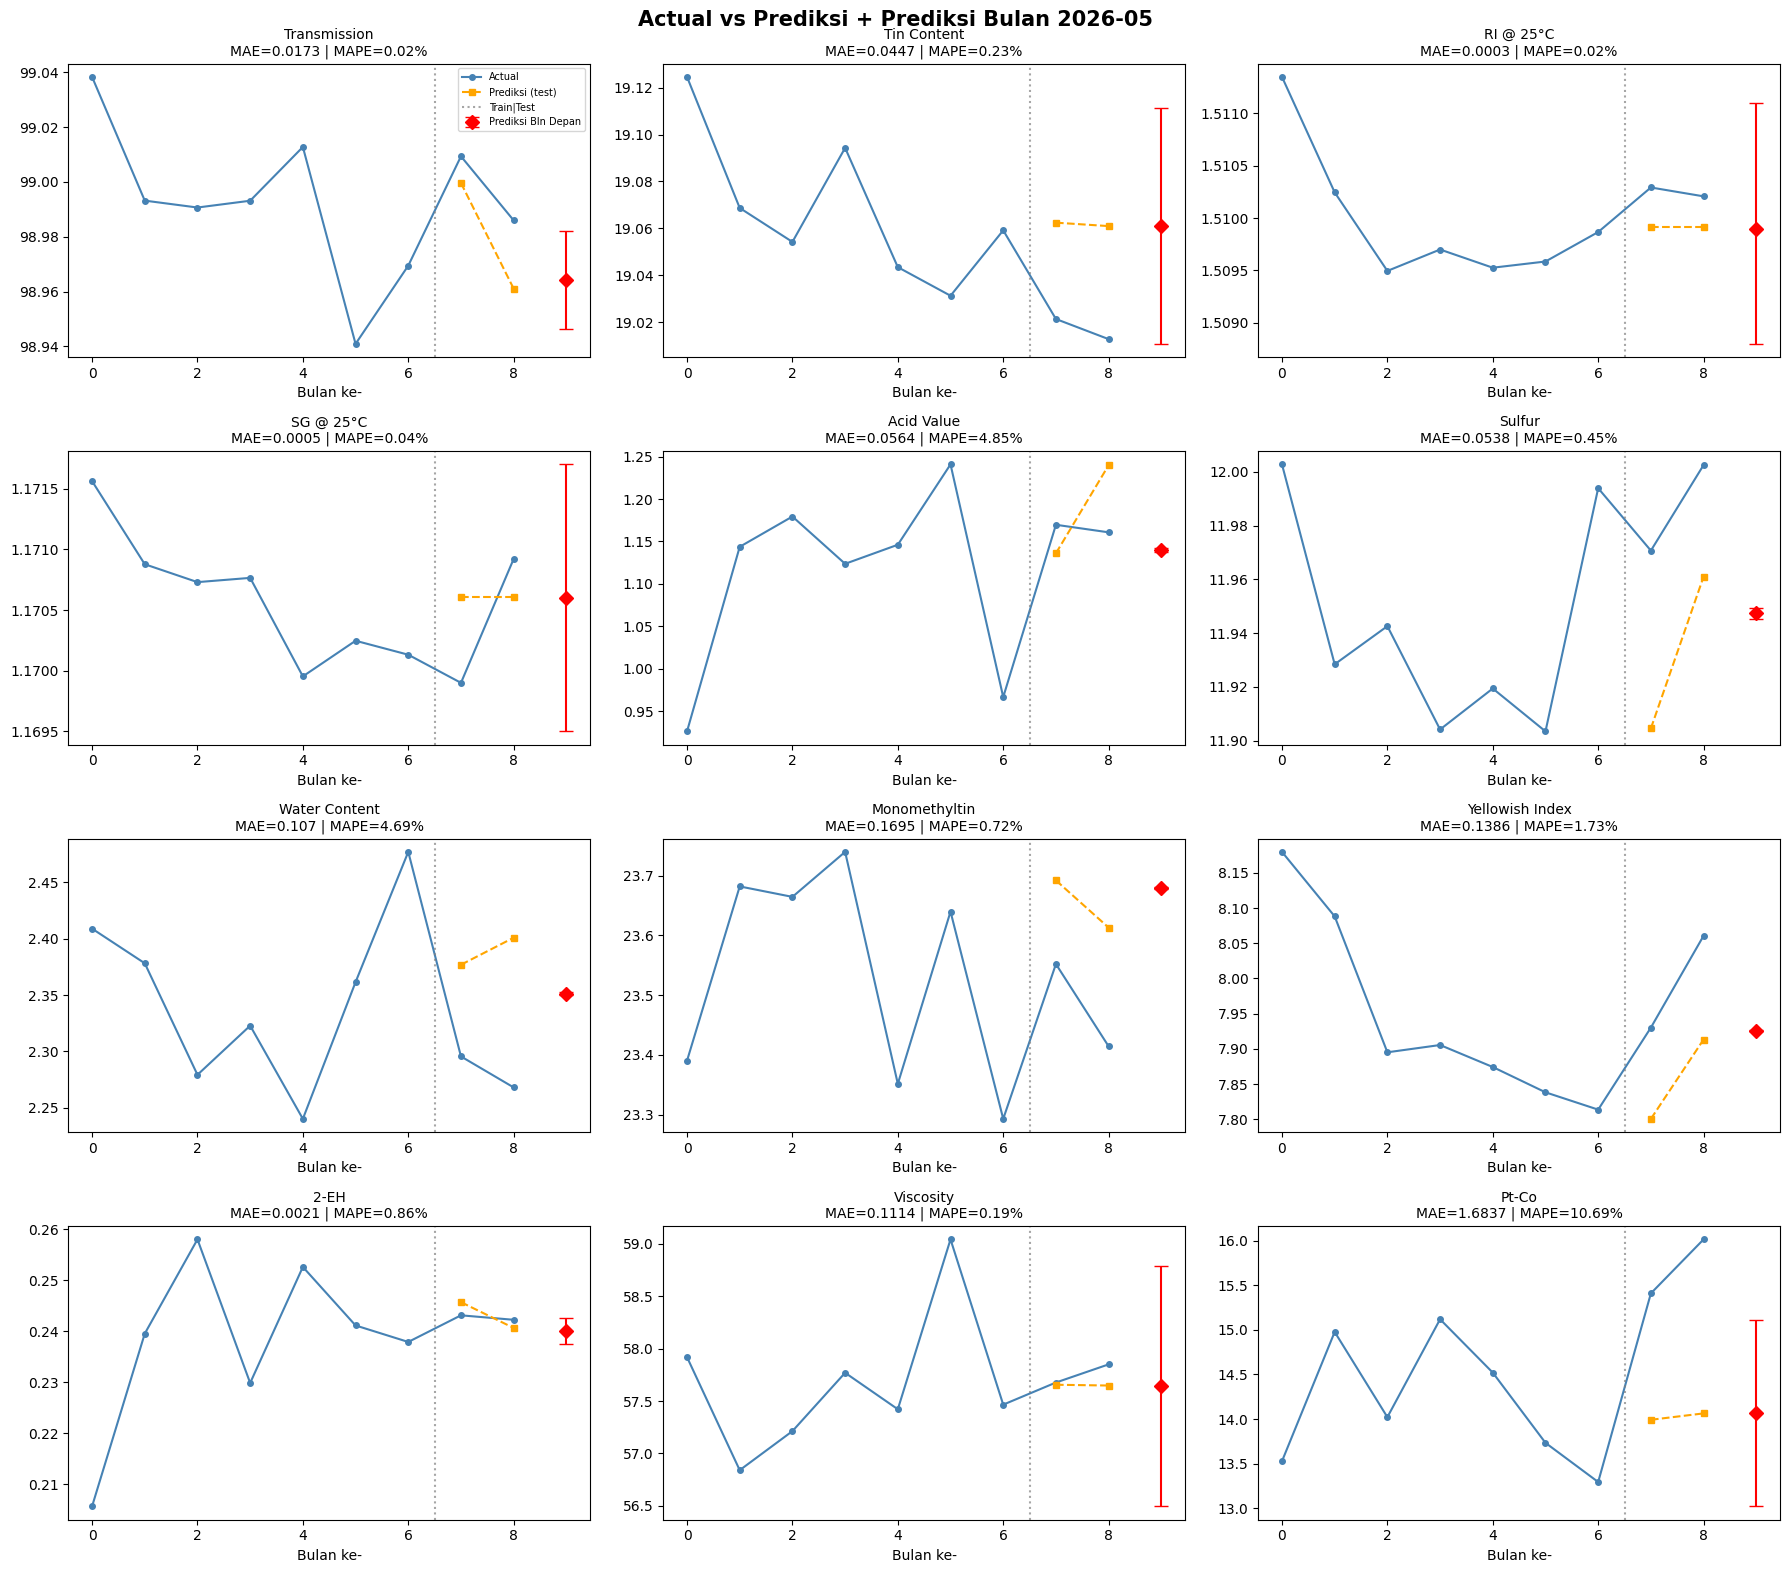

Tersimpan: grafik_prediksi_per_parameter.png


In [13]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for ax, c in zip(axes.ravel(), param_codes):
    s = splits[c]
    data = s['data']
    cut = s['cut']
    y_all = data['target'].values
    
    # Plot actual
    ax.plot(range(len(y_all)), y_all, 'o-', color='steelblue', markersize=4, label='Actual')
    
    # Plot prediksi pada test set
    y_pred_test = best_models[c].predict(s['X_test'])
    test_idx = range(cut, len(y_all))
    ax.plot(test_idx, y_pred_test, 's--', color='orange', markersize=5, label='Prediksi (test)')
    
    # Garis pembatas train/test
    ax.axvline(cut - 0.5, color='gray', linestyle=':', alpha=0.7, label='Train|Test')
    
    # Prediksi bulan depan
    row = df_pred[df_pred.Kode == c].iloc[0]
    ax.errorbar(len(y_all), row['Prediksi'],
                yerr=[[row['Prediksi'] - row['Batas Bawah 95%']],
                      [row['Batas Atas 95%'] - row['Prediksi']]],
                fmt='D', color='red', capsize=5, markersize=7, label='Prediksi Bln Depan')
    
    # Evaluasi
    ev = df_eval[df_eval.Kode == c].iloc[0]
    ax.set_title(f"{param_names[c]}\nMAE={ev['MAE']} | MAPE={ev['MAPE (%)']}%", fontsize=10)
    ax.set_xlabel('Bulan ke-')

# Legend hanya di subplot pertama
axes.ravel()[0].legend(fontsize=7, loc='best')
plt.suptitle(f'Actual vs Prediksi + Prediksi Bulan {next_month_str}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_prediksi_per_parameter.png', dpi=130, bbox_inches='tight')
plt.show()
print('Tersimpan: grafik_prediksi_per_parameter.png')

## 14. Feature Importance Per Parameter

Mengetahui fitur (lag/bulan/dll) yang paling berpengaruh untuk setiap parameter.

**Referensi:** Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* ACM SIGKDD.

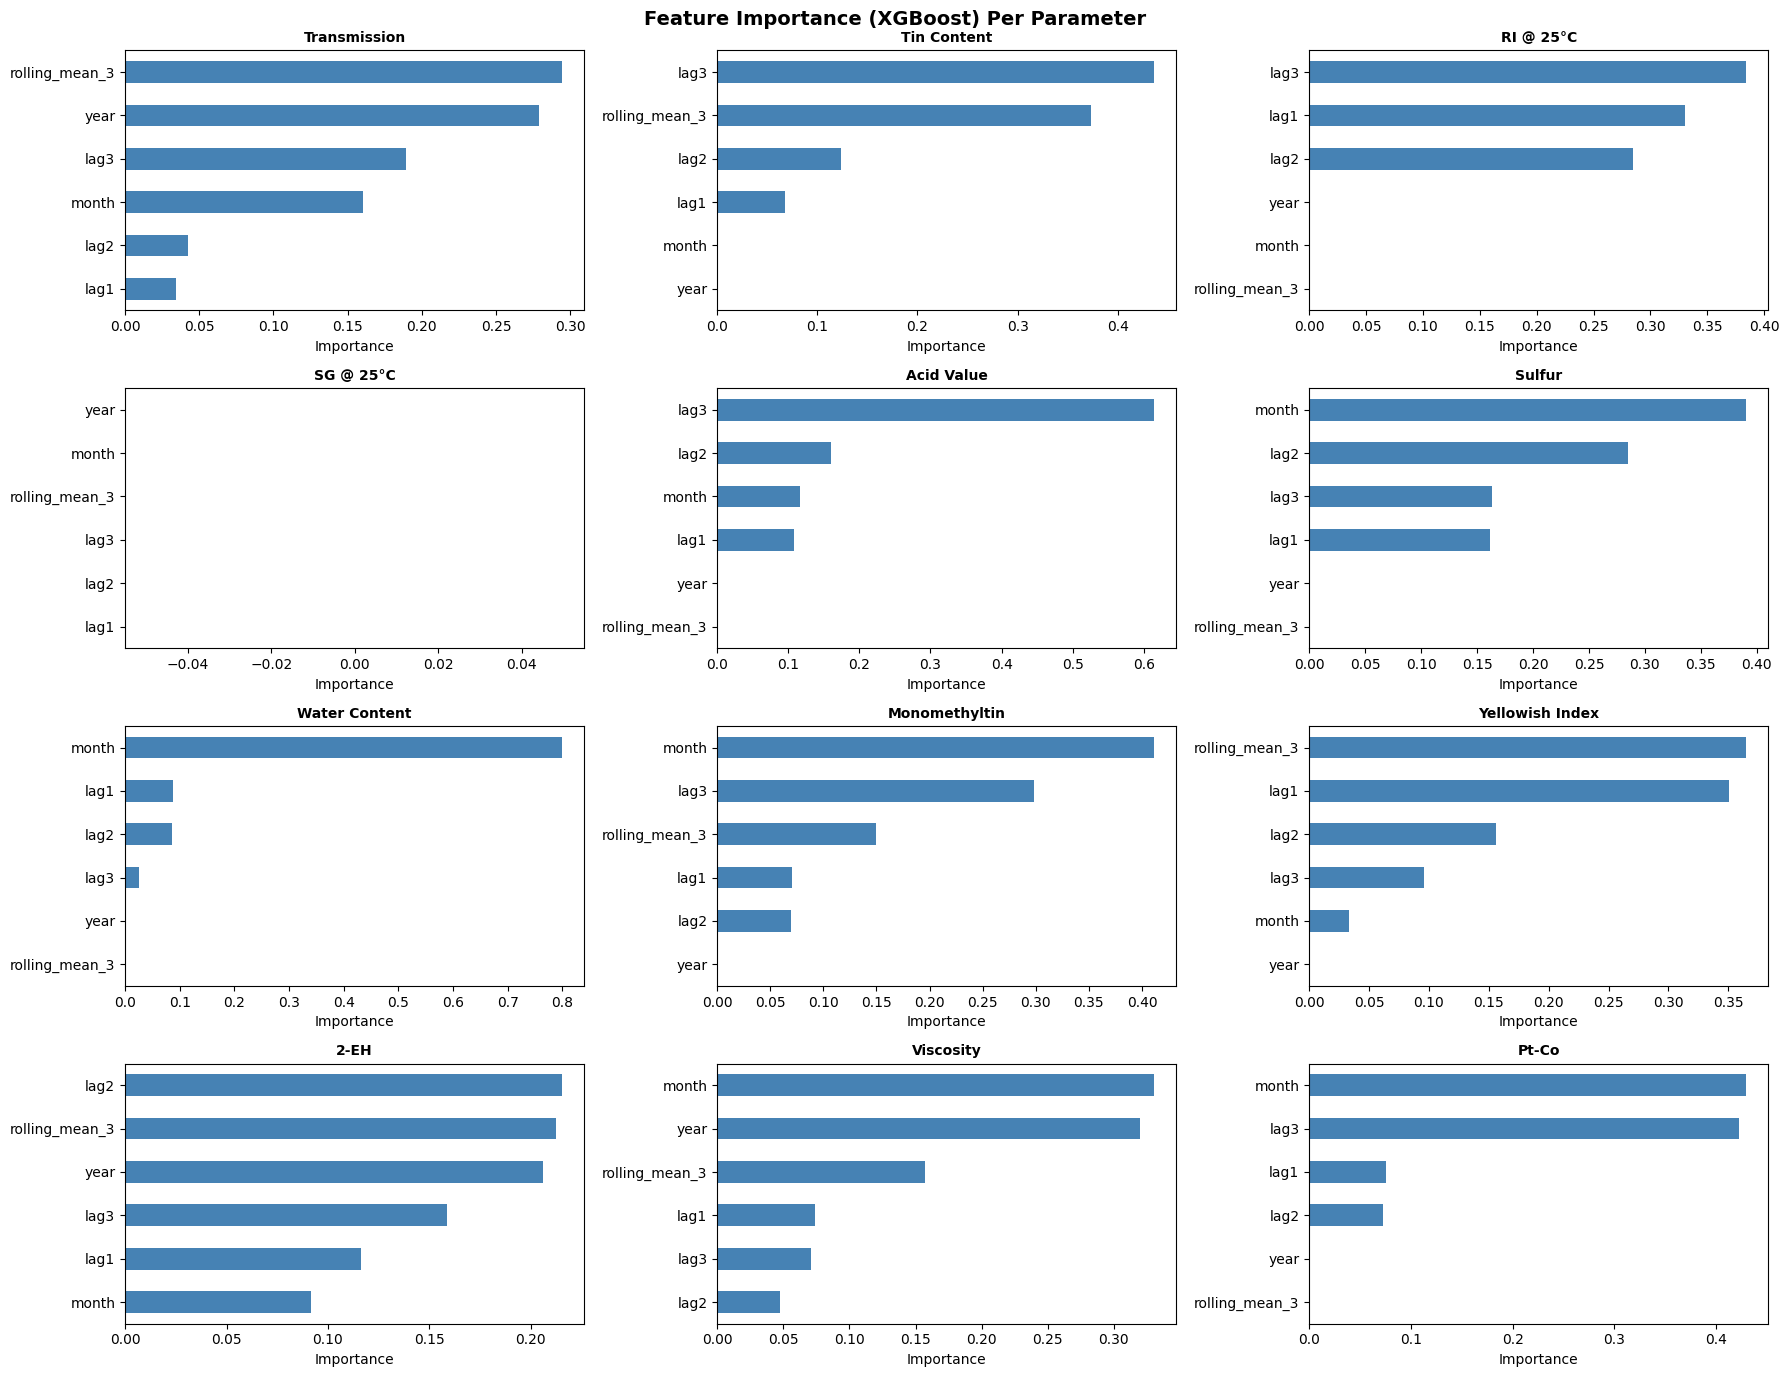

Tersimpan: feature_importance_per_parameter.png


In [14]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))

for ax, c in zip(axes.ravel(), param_codes):
    imp = pd.Series(best_models[c].feature_importances_, index=feature_cols)
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{param_names[c]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance (XGBoost) Per Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_per_parameter.png', dpi=130, bbox_inches='tight')
plt.show()
print('Tersimpan: feature_importance_per_parameter.png')

## 15. Diagnostik Residual Per Parameter

Plot residual (actual - prediksi) untuk memeriksa apakah error berpola atau random.
Residual yang baik seharusnya tersebar acak di sekitar nol.

**Referensi:** Hyndman, R. J., & Athanasopoulos, G. (2021). *FPP3*, Bab 5.3: Residual Diagnostics.

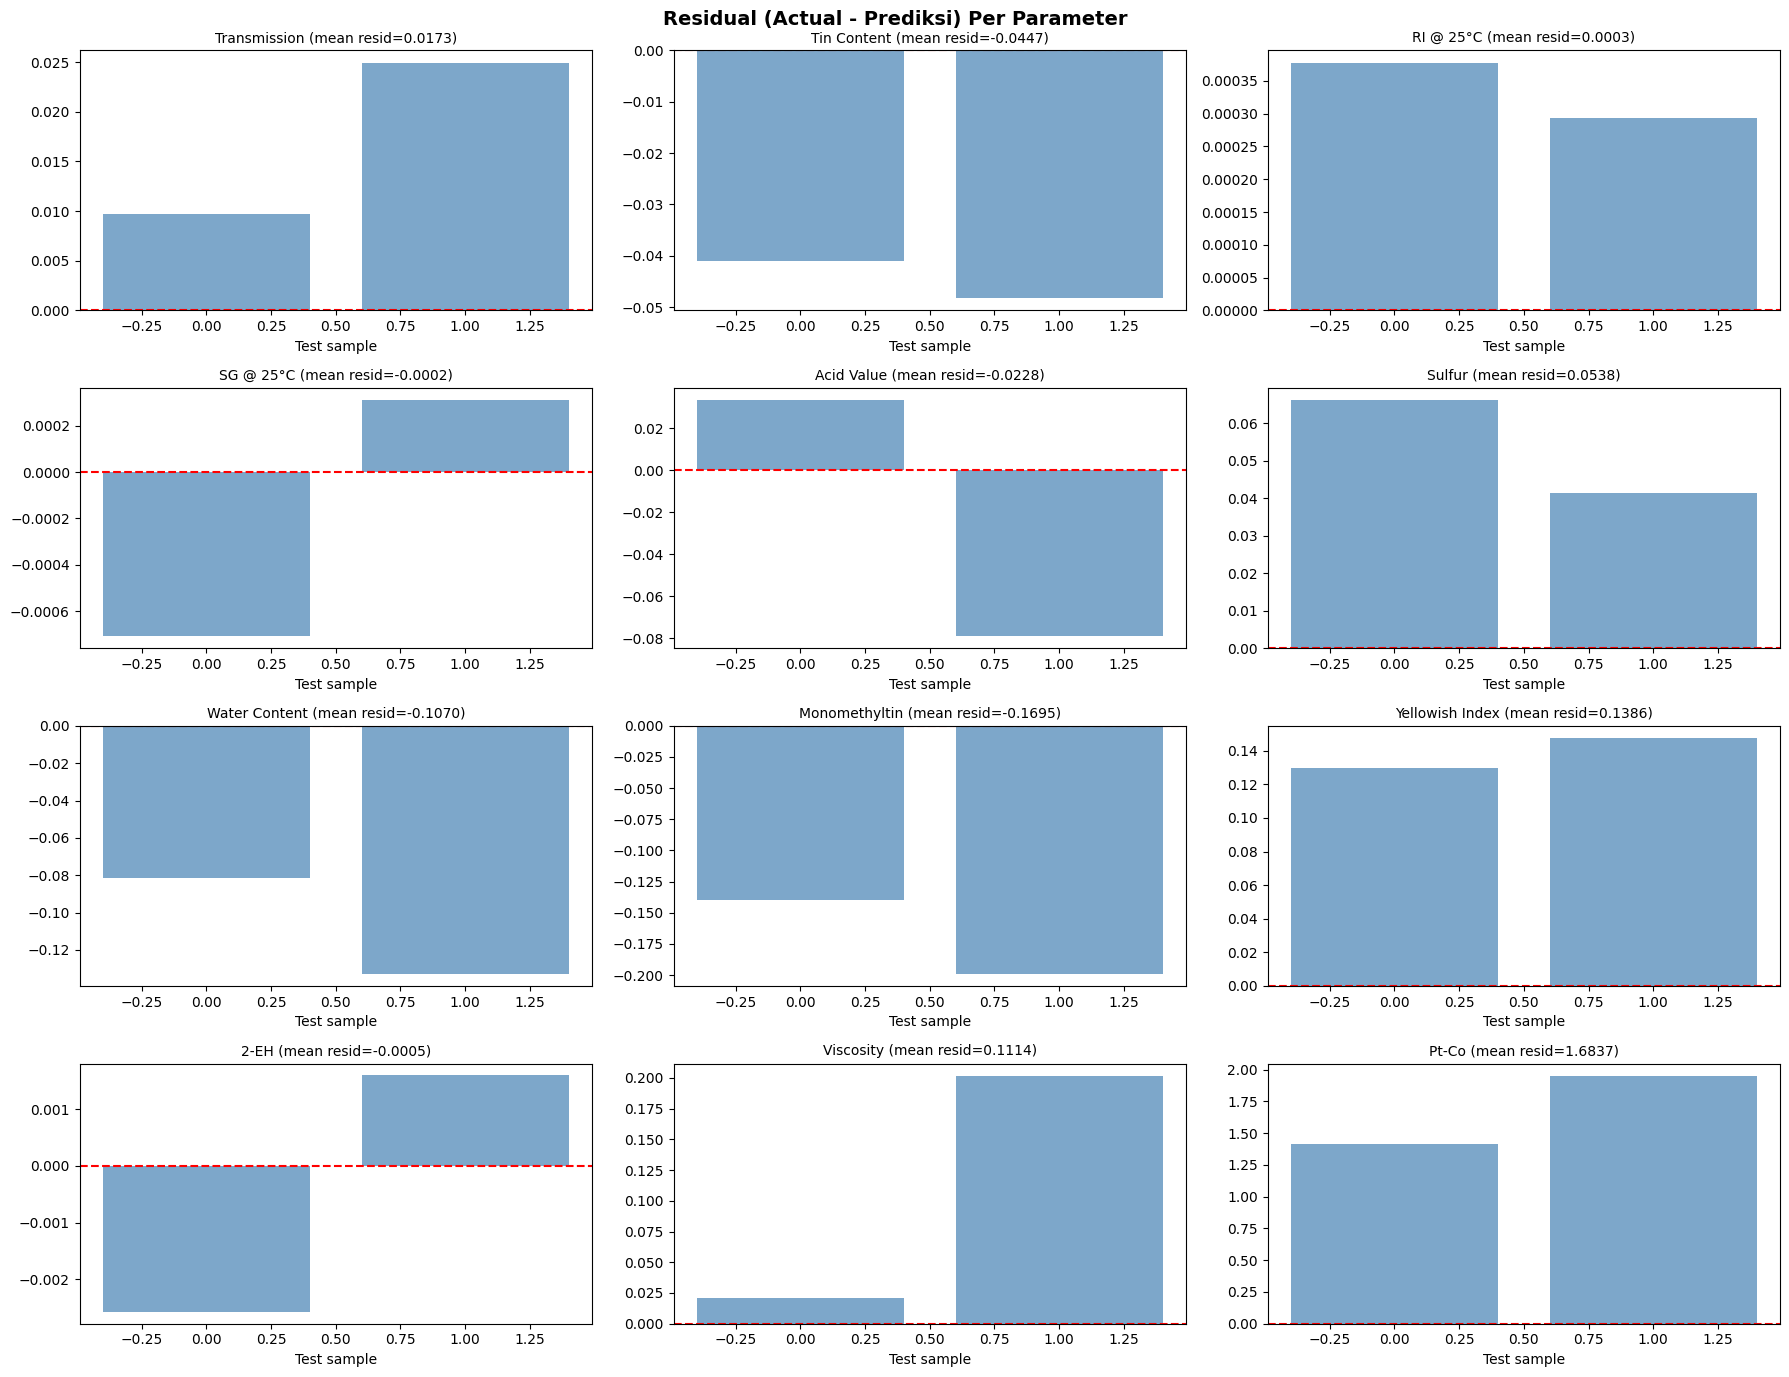

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))

for ax, c in zip(axes.ravel(), param_codes):
    s = splits[c]
    y_pred = best_models[c].predict(s['X_test'])
    resid = s['y_test'] - y_pred
    
    ax.bar(range(len(resid)), resid, color='steelblue', alpha=0.7)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'{param_names[c]} (mean resid={np.mean(resid):.4f})', fontsize=10)
    ax.set_xlabel('Test sample')

plt.suptitle('Residual (Actual - Prediksi) Per Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Tabel Ringkasan Komprehensif

Merangkum semua hasil analisis dalam satu tabel: prediksi, interval, evaluasi,
normalitas, stasioneritas, dan cross-validation.

In [16]:
# Gabungkan semua hasil
ringkasan = df_pred.copy()

# Merge evaluasi
ringkasan = ringkasan.merge(
    df_eval[['Kode','MAE','RMSE','MAPE (%)','R\u00b2','MAE Baseline','Lebih Baik?']],
    on='Kode', how='left'
)

# Merge CV
ringkasan = ringkasan.merge(
    df_cv[['Kode','Mean MAE']].rename(columns={'Mean MAE': 'CV-MAE'}),
    on='Kode', how='left'
)

# Merge walk-forward
ringkasan = ringkasan.merge(
    df_wf[['Kode','WF-MAE']],
    on='Kode', how='left'
)

# Merge normalitas
ringkasan = ringkasan.merge(
    df_normal[['Kode','p-value','Keterangan']].rename(
        columns={'p-value': 'Shapiro p', 'Keterangan': 'Normalitas'}),
    on='Kode', how='left'
)

# Merge stasioneritas
ringkasan = ringkasan.merge(
    df_stasioner[['Kode','p-value','Keterangan']].rename(
        columns={'p-value': 'ADF p', 'Keterangan': 'Stasioneritas'}),
    on='Kode', how='left'
)

print(f"=== TABEL RINGKASAN KOMPREHENSIF ===")
print(f"    Prediksi untuk bulan: {next_month_str}")
display(ringkasan)

=== TABEL RINGKASAN KOMPREHENSIF ===
    Prediksi untuk bulan: 2026-05


,Parameter,Kode,Prediksi,Batas Bawah 95%,Batas Atas 95%,Sigma Residual,MAE,RMSE,MAPE (%),R²,MAE Baseline,Lebih Baik?,CV-MAE,WF-MAE,Shapiro p,Normalitas,ADF p,Stasioneritas
0,Transmission,Transmission,98.9642,98.9462,98.9822,0.0092,0.0173,0.0189,0.02,-1.6187,0.0317,Ya,0.0299,0.0224,0.4976,Normal,0.1005,Non-Stasioner
1,Tin Content,Tin,19.0609,19.0107,19.1111,0.0256,0.0447,0.0448,0.23,-108.0092,0.0232,Tidak,0.0392,0.0409,0.9944,Normal,0.9798,Non-Stasioner
2,RI @ 25°C,RI,1.5099,1.5088,1.5111,0.0006,0.0003,0.0003,0.02,-62.9305,0.0003,Tidak,0.0004,0.0004,0.3831,Normal,0.0005,Stasioner
3,SG @ 25°C,SG,1.1706,1.1695,1.1717,0.0005,0.0005,0.0005,0.04,-0.1517,0.0006,Ya,0.0007,0.0006,0.5805,Normal,0.0231,Stasioner
4,Acid Value,Acid,1.1404,1.1380,1.1428,0.0012,0.0564,0.0608,4.85,-185.5966,0.1061,Ya,0.0923,0.0779,0.0653,Normal,0.0888,Non-Stasioner
5,Sulfur,Sulfur,11.9475,11.9454,11.9495,0.0010,0.0538,0.0552,0.45,-11.0341,0.0275,Tidak,0.0306,0.0351,0.0683,Normal,0.2350,Non-Stasioner
6,Water Content,Water,2.3511,2.3497,2.3525,0.0007,0.1070,0.1100,4.69,-63.2601,0.1044,Tidak,0.0856,0.0931,0.3121,Normal,0.1721,Non-Stasioner
7,Monomethyltin,Mono,23.6791,23.6779,23.6803,0.0006,0.1695,0.1720,0.72,-5.2287,0.1986,Ya,0.1410,0.1511,0.5515,Normal,0.0002,Stasioner
8,Yellowish Index,Yellow,7.9259,7.9247,7.9271,0.0006,0.1386,0.1388,1.73,-3.5261,0.1236,Tidak,0.1381,0.1270,0.7796,Normal,0.3015,Non-Stasioner
9,2-EH,EH,0.2401,0.2376,0.2426,0.0013,0.0021,0.0021,0.86,-22.9919,0.0030,Ya,0.0035,0.0027,0.0591,Normal,0.0149,Stasioner


## 17. Simpan Hasil

In [17]:
# Simpan tabel ringkasan
ringkasan.to_csv('ringkasan_prediksi_xgboost_per_parameter.csv', index=False)
print('Tersimpan: ringkasan_prediksi_xgboost_per_parameter.csv')

# Simpan prediksi
df_pred.to_csv('prediksi_parameter_bulan_depan.csv', index=False)
print('Tersimpan: prediksi_parameter_bulan_depan.csv')

# Simpan evaluasi
df_eval.to_csv('evaluasi_model_per_parameter.csv', index=False)
print('Tersimpan: evaluasi_model_per_parameter.csv')

# Simpan semua model
import pickle
for c in param_codes:
    best_models[c].save_model(f'model_xgboost_{c}.json')
print(f'Tersimpan: {len(param_codes)} model XGBoost (format JSON)')

Tersimpan: ringkasan_prediksi_xgboost_per_parameter.csv
Tersimpan: prediksi_parameter_bulan_depan.csv
Tersimpan: evaluasi_model_per_parameter.csv
Tersimpan: 12 model XGBoost (format JSON)


## 18. Kesimpulan & Keterbatasan

### Kesimpulan

1. **12 parameter QC** produksi MT-620 berhasil diprediksi secara **independen** menggunakan
   model XGBoost per parameter.
2. Setiap parameter memiliki **model, evaluasi, dan prediksi** sendiri sehingga hasil
   lebih **spesifik** dan **akurat** dibanding satu model untuk semua.
3. Prediksi bulan depan disertai **interval kepercayaan 95%** untuk memberikan gambaran
   ketidakpastian.
4. **Walk-forward validation** dan **TimeSeriesSplit CV** memvalidasi model secara
   realistis (meniru kondisi prediksi nyata).
5. **Feature importance** menunjukkan fitur mana yang paling berpengaruh per parameter —
   umumnya lag-1 (bulan sebelumnya) paling dominan.

### Keterbatasan

1. **Data sangat sedikit** (~12 titik bulanan) → hasil bersifat **indikatif**, bukan definitif.
   Idealnya butuh 24–36 bulan data.
2. **Tidak ada data proses produksi** (suhu, tekanan, bahan baku) yang merupakan penyebab
   nyata variasi mutu.
3. **Appearance (APE)** bersifat kategorikal dan dikecualikan dari prediksi numerik.
4. Model **belum menangkap pola musiman** karena data < 2 tahun.
5. **Overfitting** mungkin terjadi pada parameter dengan data sangat terbatas.

## Daftar Referensi

### Jurnal Ilmiah

1. Chen, T., & Guestrin, C. (2016). "XGBoost: A Scalable Tree Boosting System."
   *Proceedings of the 22nd ACM SIGKDD*, 785–794.
   [DOI: 10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)

2. Hyndman, R. J., & Koehler, A. B. (2006). "Another Look at Measures of Forecast Accuracy."
   *International Journal of Forecasting*, 22(4), 679–688.
   [DOI: 10.1016/j.ijforecast.2006.03.001](https://doi.org/10.1016/j.ijforecast.2006.03.001)

3. Bergstra, J., & Bengio, Y. (2012). "Random Search for Hyper-Parameter Optimization."
   *JMLR*, 13, 281–305. [Link](https://www.jmlr.org/papers/v13/bergstra12a.html)

4. Shapiro, S. S., & Wilk, M. B. (1965). "An Analysis of Variance Test for Normality (Complete Samples)."
   *Biometrika*, 52(3/4), 591–611. [DOI: 10.2307/2333709](https://doi.org/10.2307/2333709)

5. Dickey, D. A., & Fuller, W. A. (1979). "Distribution of the Estimators for Autoregressive Time Series
   with a Unit Root." *JASA*, 74(366), 427–431. [DOI: 10.2307/2286348](https://doi.org/10.2307/2286348)

6. Tashman, L. J. (2000). "Out-of-sample tests of forecasting accuracy: an analysis and review."
   *International Journal of Forecasting*, 16(4), 437–450.

7. Pedregosa, F., et al. (2011). "Scikit-learn: Machine Learning in Python."
   *JMLR*, 12, 2825–2830. [Link](https://www.jmlr.org/papers/v12/pedregosa11a.html)

### Buku

8. McKinney, W. (2017). *Python for Data Analysis*, 2nd Ed. O'Reilly.
   [Link](https://www.oreilly.com/library/view/python-for-data/9781491957653/)

9. Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
   [Baca Gratis Online](https://otexts.com/fpp3/)

10. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*
    (2nd ed.). Springer. [Baca Gratis Online](https://www.statlearning.com/)

### Dokumentasi Library

11. XGBoost Documentation — [Link](https://xgboost.readthedocs.io/)
12. Scikit-learn: TimeSeriesSplit — [Link](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)
13. SciPy: Shapiro-Wilk — [Link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html)
14. Statsmodels: ADF — [Link](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)